<a href="https://colab.research.google.com/github/kiristiiian/Proyecto-Telecom-X/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:


import requests
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
data_json = response.json()

df = pd.json_normalize(data_json)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación y Exploración Inicial del Dataset

---



In [ ]:

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(".", "_", regex=False)

# Ver columnas
print("Columnas del dataset:")
print(df.columns.tolist())

# Información general
print("\nInformación del dataset:")
df.info()

# Ver valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

Columnas del dataset:
['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner  


# 4. Limpieza de Datos (Transform)


In [ ]:


# Convertir columnas numéricas
df["account_Charges_Total"] = pd.to_numeric(
    df["account_Charges_Total"],
    errors="coerce"
)

df["account_Charges_Monthly"] = pd.to_numeric(
    df["account_Charges_Monthly"],
    errors="coerce"
)

df["customer_tenure"] = pd.to_numeric(
    df["customer_tenure"],
    errors="coerce"
)

# Limpiar columna Churn
df["Churn"] = df["Churn"].replace("", np.nan)
df = df.dropna(subset=["Churn"])

# Eliminar duplicados
df = df.drop_duplicates()

print("\nDataset limpio:")
df.info()


Dataset limpio:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   object 
 5   customer_Dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   object 
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   object 
 13  internet_TechSupport       7043 non-

#📊 Carga y análisis

In [ ]:


# Estadísticas descriptivas
print("\nResumen estadístico:")
print(df.describe())

# Distribución de Churn
print("\nDistribución de Churn:")
print(df["Churn"].value_counts())

print("\nProporción de Churn:")
print(df["Churn"].value_counts(normalize=True))

# Análisis por tipo de contrato
print("\nChurn por tipo de contrato:")
print(pd.crosstab(df["account_Contract"], df["Churn"], normalize="index"))


Resumen estadístico:
       customer_SeniorCitizen  customer_tenure  account_Charges_Monthly  \
count             7043.000000      7043.000000              7043.000000   
mean                 0.162147        32.371149                64.761692   
std                  0.368612        24.559481                30.090047   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.500000   
50%                  0.000000        29.000000                70.350000   
75%                  0.000000        55.000000                89.850000   
max                  1.000000        72.000000               118.750000   

       account_Charges_Total  
count            7032.000000  
mean             2283.300441  
std              2266.771362  
min                18.800000  
25%               401.450000  
50%              1397.475000  
75%              3794.737500  
max              8684.800000  

Distribución de Churn:

#Distribución General de Churn

/tmp/ipykernel_204/2517511081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


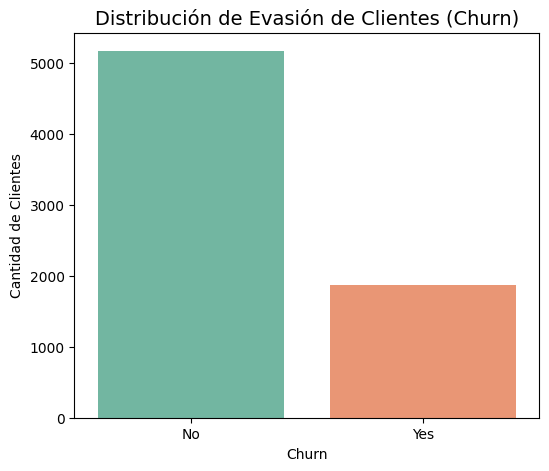

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Churn", palette="Set2")

plt.title("Distribución de Evasión de Clientes (Churn)", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Cantidad de Clientes")
plt.show()

#Churn por Tipo de Contrato (MUY IMPORTANTE)

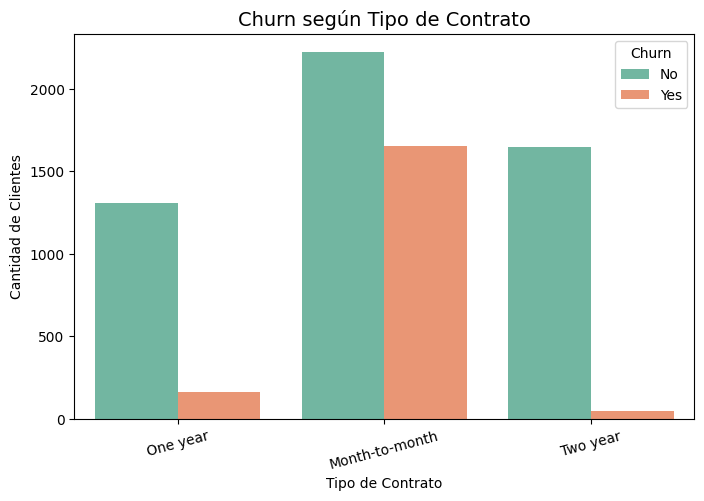

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="account_Contract", hue="Churn", palette="Set2")

plt.title("Churn según Tipo de Contrato", fontsize=14)
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")
plt.xticks(rotation=15)
plt.show()

#📄Informe final

#Churn por Método de Pago

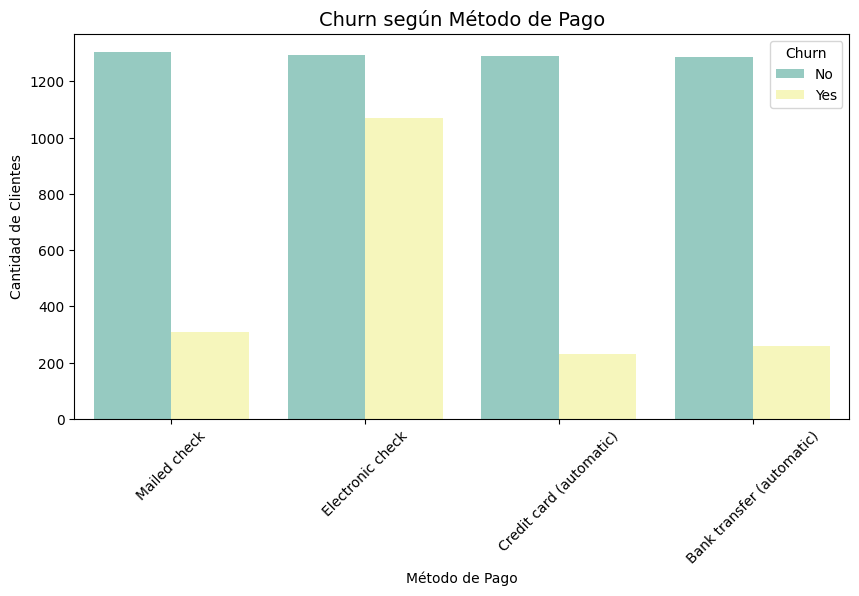

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="account_PaymentMethod", hue="Churn", palette="Set3")

plt.title("Churn según Método de Pago", fontsize=14)
plt.xlabel("Método de Pago")
plt.ylabel("Cantidad de Clientes")
plt.xticks(rotation=45)
plt.show()

#Cargos Mensuales vs Churn

/tmp/ipykernel_204/3663486056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="account_Charges_Monthly", palette="Set2")


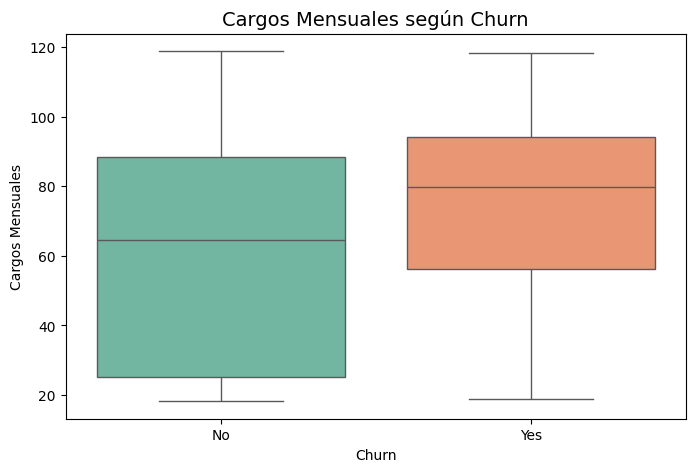

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="account_Charges_Monthly", palette="Set2")

plt.title("Cargos Mensuales según Churn", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Cargos Mensuales")
plt.show()

#Correlación (Mapa de Calor Profesional)

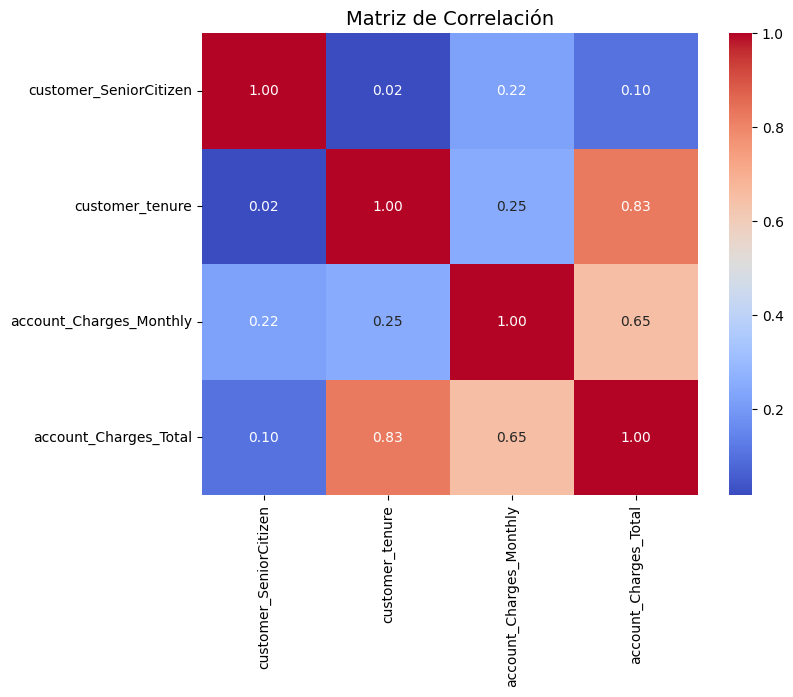

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación", fontsize=14)
plt.show()

In [ ]:
# Elimino las columnas que no necesito
df_model = df.drop(columns=["customerID"], errors="ignore")

df_model.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [ ]:
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [ ]:
# proporcion de churn
churn_counts = df["Churn"].value_counts()
print(churn_counts)

print("\nProporción:")
print(df["Churn"].value_counts(normalize=True))

#73% de los clientes NO cancelaron

#26% de los clientes Si cancelaron

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporción:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


/tmp/ipykernel_204/3794391147.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Churn"], palette="Set2")


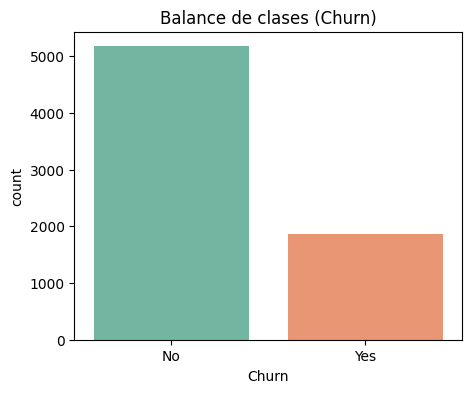

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["Churn"], palette="Set2")
plt.title("Balance de clases (Churn)")
plt.show()

In [ ]:
X = df_model.drop("Churn_Yes", axis=1)
y = df_model["Churn_Yes"]

In [ ]:
# eliminar columnas innecesarias
df_model = df.drop(columns=["customerID"], errors="ignore")

# convertir variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

# eliminar valores NaN
df_model = df_model.dropna()

# separar variables
X = df_model.drop("Churn_Yes", axis=1)
y = df_model["Churn_Yes"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8037914691943128
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1554
        True       0.64      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



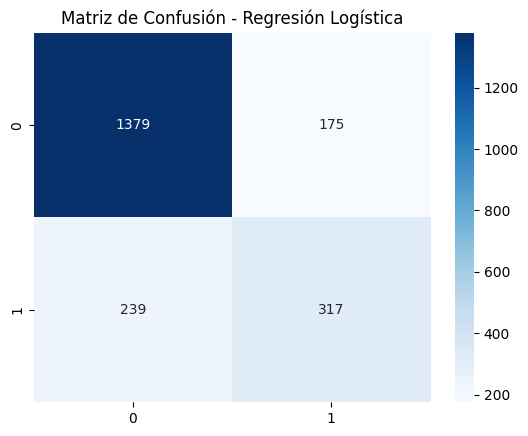

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7867298578199052
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1554
        True       0.62      0.49      0.55       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(10)

,0
account_Charges_Total,0.193704
customer_tenure,0.170820
account_Charges_Monthly,0.164731
account_PaymentMethod_Electronic check,0.036923
internet_InternetService_Fiber optic,0.036693
account_Contract_Two year,0.031867
customer_gender_Male,0.028356
internet_OnlineSecurity_Yes,0.027988
account_PaperlessBilling_Yes,0.026246
internet_TechSupport_Yes,0.024500


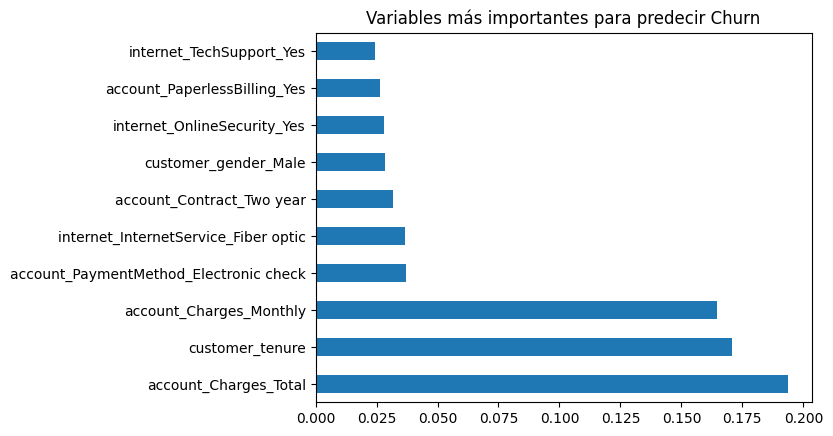

In [ ]:
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Variables más importantes para predecir Churn")
plt.show()